# IMPORTS

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import List, Tuple, Callable, Dict
import time

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# ANN ARCHITECTURE


In [4]:
class neural_network:
    def __init__(self, Layer_Size: List[int], Activation_Function: List[str]):
        self.Layer_Size = Layer_Size
        self.num_layers = len(Layer_Size)
        self.Activation_Function = Activation_Function
        self.weights = []
        self.biases = []
        
        self.num_parameters = 0
        for i in range(len(Layer_Size) - 1):
            self.num_parameters += Layer_Size[i] * Layer_Size[i + 1]
            self.num_parameters += Layer_Size[i + 1]
    
    def Parameter_setup(self, params: np.ndarray):
        # Weights and biases setup
        self.weights = []
        self.biases = []
        idx = 0
        for i in range(len(self.Layer_Size) - 1):
            Num_weight = self.Layer_Size[i] * self.Layer_Size[i + 1]
            w = params[idx:idx + Num_weight].reshape(self.Layer_Size[i], self.Layer_Size[i + 1])
            self.weights.append(w)
            idx += Num_weight
            
            b = params[idx:idx + self.Layer_Size[i + 1]]
            self.biases.append(b)
            idx += self.Layer_Size[i + 1]
    
    def Activate(self, x: np.ndarray, FunctionName: str) -> np.ndarray:
        # Activation function
        if FunctionName == 'logistic':
            return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        elif FunctionName == 'relu':
            return np.maximum(0, x)
        elif FunctionName == 'leaky_relu':
            return np.where(x > 0, x, 0.01 * x)
        elif FunctionName == 'tanh':
            return np.tanh(x)
        elif FunctionName == 'linear':
            return x
        elif FunctionName == 'elu':
            return np.where(x > 0, x, np.exp(x) - 1)
        elif FunctionName == 'swish':
            return x / (1 + np.exp(-np.clip(x, -500, 500)))
        else:
            raise ValueError(f"Unknown activation function: {FunctionName}")
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        # Forward pass through network
        activation = X
        for i in range(len(self.weights)):
            z = np.dot(activation, self.weights[i]) + self.biases[i]
            activation = self.Activate(z, self.Activation_Function[i])
        return activation
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        # Make predictions
        return self.forward(X)


class NeuralNetworkAdapted(neural_network):
    # Improved version of ANN with PSO-optimizable activation functions
    
    def __init__(self, Layer_Size: List[int], activation_options: List[str] = None):
        super().__init__(Layer_Size, ['linear'] * (len(Layer_Size) - 1))
        self.activation_options = activation_options or ['logistic', 'relu', 'tanh', 'linear', 'leaky_relu', 'elu', 'swish']
        self.ActivationIndices = [0] * (len(Layer_Size) - 1)
        # Parameters of activation functions
        self.num_parameters += len(self.ActivationIndices)
    
    def Parameters_with_activations(self, params: np.ndarray):
        # Weights, biases and activation function indices setup
        # Initial setup of weights and biases which are the main parameters
        main_parameter = params[:-len(self.ActivationIndices)]
        super().Parameter_setup(main_parameter)
        
        # Extraction of activation indices which is last n-1 parameters
        activation_parameter = params[-len(self.ActivationIndices):]
        self.ActivationIndices = np.clip(
            np.round(activation_parameter * (len(self.activation_options) - 1)), 
            0, len(self.activation_options) - 1
        ).astype(int)
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        # Forward pass with adaptive activation functions
        activation = X
        for i in range(len(self.weights)):
            z = np.dot(activation, self.weights[i]) + self.biases[i]
            Activation_Name = self.activation_options[self.ActivationIndices[i]]
            activation = self.Activate(z, Activation_Name)
        return activation

print("ANN implementation done")

ANN implementation done


# PSO PRODUCTION ALGORITHM 39 WITH PSEUDOCODE MAPPING

In [5]:
# Production Algorithm 39 PSO with Pseudocode Mapping.
class Particle39:
    # Improved exploration using prodction grade particle.
    def __init__(self, dimensions: int, bounds: Tuple[float, float], UseXavier: bool = True):
        # Algorithm 39 with random initialization
        if UseXavier:
            limit = np.sqrt(6.0 / dimensions)
            self.position = np.random.uniform(-limit, limit, dimensions)
        else:
            self.position = np.random.uniform(bounds[0], bounds[1], dimensions)
        
        # Higher initial velocity for exploration.
        Velocity_range = (bounds[1] - bounds[0]) * 0.3
        self.velocity = np.random.uniform(-Velocity_range, Velocity_range, dimensions)
        
        self.fitness = float('inf')
        self.best_position = self.position.copy()
        self.best_fitness = float('inf')
        self.bounds = bounds
        self.dimensions = dimensions
        self.improvement_counter = 0
        self.age = 0


class PSO_Algo39_Prod:
    # Use of production algorithm 39 for parameter controlled PSO.
    # Pseudocode reference: Algorithm 39 for PSOfrom "Essentials of Metaheuristics".
    def __init__(self, num_particles: int, dimensions: int, bounds: Tuple[float, float],
                 alpha: float = 0.729, beta: float = 1.494, gamma: float = 1.494, 
                 delta: float = 0.3, epsilon: float = 0.01, Num_Informants: int = 3,
                 Boundary_handling: str = 'clamp', Use_Adaptive: bool = True, 
                 UseXavier: bool = True, verbose: bool = False):
        
        # Algorithm 39 parameters
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.epsilon = epsilon
        
        # Initial values store
        self.alpha_start = alpha
        self.beta_start = beta
        self.gamma_start = gamma
        self.delta_start = delta
        self.epsilon_start = epsilon
        
        # PSO configuration
        self.num_particles = num_particles
        self.dimensions = dimensions
        self.bounds = bounds
        self.Num_Informants = min(Num_Informants, num_particles - 1)
        self.Boundary_handling = Boundary_handling
        self.Use_Adaptive = Use_Adaptive
        self.verbose = verbose
        
        # Constriction factor
        self.constriction = 0.7298
        
        # Algorithm 39 with initialization of particles.
        self.swarm = [Particle39(dimensions, bounds, UseXavier) for _ in range(num_particles)]
        self.Informants = self.Informants_initialization()
        
        # Best tracking
        self.global_best_position = None
        self.global_best_fitness = float('inf')
        self.fitness_history = []
        self.diversity_history = []
        self.parameter_history = {'alpha': [], 'beta': [], 'gamma': [], 'delta': [], 'epsilon': []}
        
        # Stagnation tracking
        self.no_improvement_count = 0
        self.best_fitness_history = []
        self.regeneration_threshold = 30
    
    def Informants_initialization(self) -> List[List[int]]:
        # Initialization of neighborhood topology for algorithm 39 
        Informants = []
        for i in range(self.num_particles):
            Particle_informants = [i]
            others = [j for j in range(self.num_particles) if j != i]
            Num_additional = min(self.Num_Informants - 1, len(others))
            if Num_additional > 0:
                Particle_informants.extend(random.sample(others, Num_additional))
            Informants.append(Particle_informants)
        return Informants
    
    def Neighborhood_best(self, particle_idx: int) -> Tuple[np.ndarray, float]:
        # To get the best in neighborhood with Algorithm 39 
        best_fitness = float('inf')
        best_position = None
        
        for informant_idx in self.Informants[particle_idx]:
            if self.swarm[informant_idx].best_fitness < best_fitness:
                best_fitness = self.swarm[informant_idx].best_fitness
                best_position = self.swarm[informant_idx].best_position.copy()
        
        return best_position, best_fitness
    
    def Boundary_handling_app(self, particle: Particle39):
        # Application of boundary condition with multiple methods for enhance.
        if self.Boundary_handling == 'clamp':
            particle.position = np.clip(particle.position, self.bounds[0], self.bounds[1])
        elif self.Boundary_handling == 'reflect':
            for d in range(self.dimensions):
                if particle.position[d] < self.bounds[0]:
                    particle.position[d] = self.bounds[0] + (self.bounds[0] - particle.position[d])
                    particle.velocity[d] *= -0.5
                elif particle.position[d] > self.bounds[1]:
                    particle.position[d] = self.bounds[1] - (particle.position[d] - self.bounds[1])
                    particle.velocity[d] *= -0.5
        elif self.Boundary_handling == 'random':
            for d in range(self.dimensions):
                if particle.position[d] < self.bounds[0] or particle.position[d] > self.bounds[1]:
                    particle.position[d] = np.random.uniform(self.bounds[0], self.bounds[1])
                    particle.velocity[d] = np.random.uniform(-1, 1)
    
    def Calculate_diversity(self) -> float:
        # Swarm diversity calculation
        positions = np.array([p.position for p in self.swarm])
        mean_pos = np.mean(positions, axis=0)
        diversity = np.mean(np.sqrt(np.sum((positions - mean_pos)**2, axis=1)))
        return diversity
    
    def Regenerate_worst_particles(self, num_to_regenerate: int = 5):
        # Regenerate worst particles using perturbations
        fitnesses = [p.best_fitness for p in self.swarm]
        Worst_indices = np.argsort(fitnesses)[-num_to_regenerate:]
        
        for idx in Worst_indices:
            # Perturbation around global best
            perturbation = np.random.normal(0, 0.2, self.dimensions)
            self.swarm[idx].position = self.global_best_position + perturbation
            self.Boundary_handling_app(self.swarm[idx])
            
            # Reset velocity
            Velocity_range = (self.bounds[1] - self.bounds[0]) * 0.2
            self.swarm[idx].velocity = np.random.uniform(-Velocity_range, Velocity_range, self.dimensions)
    
    def Parameter_adapt(self, iteration: int, max_iterations: int):
        # Enhanced version of adaptive parameter control.
        if not self.Use_Adaptive:
            return
        
        progress = iteration / max_iterations
        
        # Smooth adaptation of exploration to exploitation
        self.alpha = self.alpha_start * (1.0 - 0.3 * progress)
        self.beta = self.beta_start * (1.0 - 0.1 * progress)
        self.gamma = self.gamma_start * (1.0 + 0.1 * progress)
        self.delta = self.delta_start * (1.0 + 0.2 * progress)
        
        # Enhanced the epsilon increases exploration when stuck.
        if self.no_improvement_count > 20:
            self.epsilon = self.epsilon_start * 2.0
        else:
            self.epsilon = self.epsilon_start * (1.0 - 0.5 * progress)
        
        self.parameter_history['alpha'].append(self.alpha)
        self.parameter_history['beta'].append(self.beta)
        self.parameter_history['gamma'].append(self.gamma)
        self.parameter_history['delta'].append(self.delta)
        self.parameter_history['epsilon'].append(self.epsilon)

    def optimize(self, Fitness_function: Callable, max_iterations: int):
        
        # Production Algorithm 39 optimization loop
        # Pseudocode mapping done as comments
        if self.verbose:
            print("  [PSO] Initializing swarm....")
        
        # Initial fitness assessment -Algorithm 39 line 3
        for particle in self.swarm:
            particle.fitness = Fitness_function(particle.position)  # Algorithm 39 Line 3
            particle.best_fitness = particle.fitness  # Algorithm 39 Line 4
            particle.best_position = particle.position.copy()  # Algorithm 39 Line 4
            
            # Update global best -Algorithm 39 line 5
            if particle.fitness < self.global_best_fitness:
                self.global_best_fitness = particle.fitness
                self.global_best_position = particle.position.copy()
        
        if self.verbose:
            print(f"  [PSO] Initial fitness: {self.global_best_fitness:.8f}")
        
        # Main loop -Algorithm 39 line 6
        for iteration in range(max_iterations):  # Algorithm 39 Line 6
            self.Parameter_adapt(iteration, max_iterations)
            
            # Updation and evaluation of the personal best -Algorithm 39 line 7
            for i, particle in enumerate(self.swarm):
                particle.fitness = Fitness_function(particle.position)  # Algorithm 39 Line 7
                
                # Updation of personal best - Algorithm 39 line 8
                if particle.fitness < particle.best_fitness:
                    particle.best_fitness = particle.fitness
                    particle.best_position = particle.position.copy()
                    particle.improvement_counter = 0
                else:
                    particle.improvement_counter += 1
                
                # Updation of global best -Algorithm 39 line 9
                if particle.fitness < self.global_best_fitness:
                    self.global_best_fitness = particle.fitness
                    self.global_best_position = particle.position.copy()
                    self.no_improvement_count = 0
            
            # Each particle's velocity updation - Algorithm 39 line 10
            for i, particle in enumerate(self.swarm):
                # Get informant best -Algorithm 39 Line 10a
                x_plus, _ = self.Neighborhood_best(i)
                
                # Velocity update with cognitive/social components -Algorithm 39 Line 10b
                new_velocity = np.zeros(self.dimensions)
                
                for d in range(self.dimensions):
                    # Random velocity and coefficient components -Algorithm 39 Line 10c
                    b = np.random.uniform(0.0, self.beta)  # Cognitive coefficient 
                    d_coef = np.random.uniform(0.0, self.delta)  # Social-global coefficient
                    c = np.random.uniform(0.0, self.gamma)  # Social-local coefficient
                    
                    # Velocity components -Algorithm 39 Line 10c
                    cognitive = b * (particle.best_position[d] - particle.position[d])
                    Social_global = d_coef * (self.global_best_position[d] - particle.position[d])
                    Social_local = c * (x_plus[d] - particle.position[d])
                    
                    # Updation of velocity equation -Algorithm 39 Line 10d
                    new_velocity[d] = self.constriction * (
                        self.alpha * particle.velocity[d] + 
                        cognitive + Social_local + Social_global
                    )
                
                particle.velocity = new_velocity
            
            # Position update -Algorithm 39 Line 11
            for particle in self.swarm:
                particle.position = particle.position + particle.velocity  # Algorith 39 Line 11
                self.Boundary_handling_app(particle)  # Boundary handling
                particle.age += 1
            
            # Enhanced improvement
            improvement = self.best_fitness_history[-1] - self.global_best_fitness if self.best_fitness_history else float('inf')
            if improvement < 1e-9:
                self.no_improvement_count += 1
            else:
                self.no_improvement_count = 0
            
            # If stuck particles are regenerates.
            if self.no_improvement_count > self.regeneration_threshold:
                if self.verbose:
                    print(f"[PSO] Regenerating particles at iteration num {iteration + 1}")
                self.Regenerate_worst_particles(num_to_regenerate=5)
                self.no_improvement_count = 0
            
            # Track metrics
            diversity = self.Calculate_diversity()
            self.diversity_history.append(diversity)
            self.fitness_history.append(self.global_best_fitness)
            self.best_fitness_history.append(self.global_best_fitness)
            
            # Progress reporting
            if (iteration + 1) % max(1, max_iterations // 10) == 0:
                if self.verbose:
                    print(f"PSO Iteration {iteration + 1:3d}/{max_iterations}: "
                          f"Best:{self.global_best_fitness:.8f}, Diversity:{diversity:.6f}, "
                          f"Epsilon={self.epsilon:.6f}, No_Improvement:{self.no_improvement_count}")
        
        if self.verbose:
            print(f"PSO optimization done. Final: {self.global_best_fitness:.8f}")
        
        return self.global_best_position, self.global_best_fitness


print("Implementation of Production Algorithm 39 of PSO done")

Implementation of Production Algorithm 39 of PSO done


# ANN AND PSO COUPLED IMPLEMENTATION

In [6]:
# ANN-PSO Optimizer
class ANN_PSO:
    def __init__(self, Layer_Size: List[int], Activation_Function: List[str],
                 X_train: np.ndarray, y_train: np.ndarray,
                 X_test: np.ndarray, y_test: np.ndarray,
                 regularization: float = 0.0001,
                 Adaptive_activations: bool = False):
        self.Layer_Size = Layer_Size
        self.Activation_Function = Activation_Function
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.regularization = regularization
        self.Adaptive_activations = Adaptive_activations
        
        if Adaptive_activations:
            self.ann = NeuralNetworkAdapted(Layer_Size)
        else:
            self.ann = neural_network(Layer_Size, Activation_Function)
            
        self.num_parameters = self.ann.num_parameters
        self.eval_count = 0
    
    def Fitness_function(self, parameters: np.ndarray) -> float:
        self.eval_count += 1
        if self.Adaptive_activations:
            self.ann.Parameters_with_activations(parameters)
        else:
            self.ann.Parameter_setup(parameters)
            
        predictions = self.ann.predict(self.X_train)
        
        mse = np.mean((predictions.flatten() - self.y_train.flatten())**2)
        l2_penalty = self.regularization * np.sum(parameters ** 2)
        
        return mse + l2_penalty
    
    def Evaluation_test(self, parameters: np.ndarray) -> Tuple[float, float, float]:
        if self.Adaptive_activations:
            self.ann.Parameters_with_activations(parameters)
        else:
            self.ann.Parameter_setup(parameters)
            
        predictions = self.ann.predict(self.X_test)
        
        mae = np.mean(np.abs(predictions.flatten() - self.y_test.flatten()))
        rmse = np.sqrt(np.mean((predictions.flatten() - self.y_test.flatten())**2))
        
        ss_res = np.sum((self.y_test.flatten() - predictions.flatten())**2)
        ss_tot = np.sum((self.y_test.flatten() - np.mean(self.y_test.flatten()))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        return mae, rmse, r2
    
    def train(self, num_particles: int = 50, max_iterations: int = 150,
             Num_Informants: int = 5, alpha: float = 0.729, beta: float = 1.494,
             gamma: float = 1.494, delta: float = 0.3, epsilon: float = 0.01,
             bounds: Tuple[float, float] = (-1, 1),
             Boundary_handling: str = 'reflect', Use_Adaptive: bool = True,
             verbose: bool = False) -> Dict:
        
        if verbose:
            print(f"\n{'-'*75}")
            print(f"Training with Algorithm 39")
            print(f"  Swarm: {num_particles}, Iterations: {max_iterations}")
            print(f"  Parameters: Alpha={alpha:.5f}, Beta={beta:.5f}, Gamma={gamma:.5f}, Delta={delta:.5f}, Epsilon={epsilon:.5f}")
            print(f"{'-'*75}")
        
        pso = PSO_Algo39_Prod(num_particles, self.num_parameters, bounds, alpha, beta, gamma, delta, 
                             epsilon, Num_Informants, Boundary_handling, Use_Adaptive, 
                             UseXavier=True, verbose=verbose)
        
        start_time = time.time()
        best_parameters, best_train_fitness = pso.optimize(self.Fitness_function, max_iterations)
        elapsed_time = time.time() - start_time
        
        test_mae, test_rmse, test_r2 = self.Evaluation_test(best_parameters)
        
        if verbose:
            print(f"\n Results :- Train:{best_train_fitness:.7f}, Test_MAE:{test_mae:.7f}, "
                  f"Test_RMSE={test_rmse:.7f}, R²={test_r2:.7f}")
            print(f"Time: {elapsed_time:.2f}s | Evaluations: {self.eval_count}")
        
        return {
            'best_parameters': best_parameters,
            'train_mae': best_train_fitness,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
            'fitness_history': pso.fitness_history,
            'diversity_history': pso.diversity_history,
            'parameter_history': pso.parameter_history,
            'pso_object': pso,
            'time_elapsed': elapsed_time,
            'eval_count': self.eval_count
        }

print("ANN-PSO optimizer implementation done")

ANN-PSO optimizer implementation done


# EXPERIMENTAL INVESTIGATION MODULE

In [7]:
# EXPERIMENTAL INVESTIGATION MODULE
class Experimental_investigator:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train  
        self.X_test = X_test
        self.y_test = y_test
    
    def Run_architecture(self, num_runs=10):
        # ANN Architecture Effects
        architectures = [
            [8, 16, 1],      # Small - 2 hidden layers
            [8, 32, 16, 1],  # Medium - 3 hidden layers  
            [8, 64, 32, 16, 1],  # Large - 4 hidden layers
            [8, 128, 64, 32, 16, 1]  # Very Large - 5 hidden layers
        ]
        
        print(f"Testing {len(architectures)} architectures with {num_runs} runs each....")
        results = {}
        
        for i, arch in enumerate(architectures):
            print(f"  Architecture {i+1}/{len(architectures)}: {arch}")
            arch_results = []
            
            for run in range(num_runs):
                if (run + 1) % 5 == 0:
                    print(f"    Run {run + 1}/{num_runs}")
                    
                optimizer = ANN_PSO(
                    Layer_Size=arch,
                    Activation_Function=['relu']*(len(arch)-2) + ['linear'],
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test,
                    regularization=0.0001
                )
                result = optimizer.train(
                    num_particles=30, 
                    max_iterations=50, 
                    verbose=False,
                    bounds=(-0.5, 0.5)
                )
                arch_results.append(result['test_r2'])
            
            results[str(arch)] = {
                'mean_r2': np.mean(arch_results),
                'std_r2': np.std(arch_results),
                'all_runs': arch_results
            }
        
        return results
    
    def Run_allocation(self, fixed_budget=500, num_runs=10):
        # Fixed evaluation budget comparison
        # Fixed budget allocations
        allocations = [
            (10, 50),   # 10 particles * 50 iterations = 500
            (20, 25),   # 20 particles * 25 iterations = 500
            (25, 20),   # 25 particles * 20 iterations = 500  
            (50, 10),   # 50 particles * 10 iterations = 500
        ]
        
        # Verification of fixed budget
        for particles, iterations in allocations:
            Actual_budget = particles * iterations
            assert Actual_budget == fixed_budget, f"Budget violation: {particles}*{iterations} = {Actual_budget}, expected {fixed_budget}"
        
        print(f"Testing {len(allocations)} allocations with fixed budget of {fixed_budget} evaluations ({num_runs} runs )")
        results = {}
        
        for particles, iterations in allocations:
            print(f"  Allocation: {particles} particles * {iterations} iterations = {particles * iterations} evaluations")
            alloc_results = []
            
            for run in range(num_runs):
                if (run + 1) % 5 == 0:
                    print(f"    Run {run + 1}/{num_runs}")
                    
                optimizer = ANN_PSO(
                    Layer_Size=[8, 32, 16, 1],
                    Activation_Function=['relu', 'relu', 'linear'],
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test,
                    regularization=0.0001
                )
                result = optimizer.train(
                    num_particles=particles, 
                    max_iterations=iterations, 
                    verbose=False,
                    bounds=(-0.5, 0.5)
                )
                alloc_results.append(result['test_r2'])
            
            results[f"{particles}p_{iterations}i"] = {
                'mean_r2': np.mean(alloc_results),
                'std_r2': np.std(alloc_results),
                'all_runs': alloc_results,
                'evaluations': particles * iterations  # Actual evaluation track
            }
        
        return results
    
    def Run_coefficient(self, num_runs=10):
        # Acceleration coefficients
        coef_sets = {
            'High_Cognitive': {'alpha': 0.7, 'beta': 2.0, 'gamma': 1.0, 'delta': 0.1},
            'High_Social': {'alpha': 0.7, 'beta': 1.0, 'gamma': 2.0, 'delta': 0.3},
            'Balanced': {'alpha': 0.7, 'beta': 1.5, 'gamma': 1.5, 'delta': 0.2},
            'Explorative': {'alpha': 0.9, 'beta': 0.5, 'gamma': 0.5, 'delta': 0.1},
        }
        
        print(f"Testing {len(coef_sets)} coefficient sets with {num_runs} runs each....")
        results = {}
        
        for name, coeffs in coef_sets.items():
            print(f"  Coefficient Set: {name}")
            coeff_results = []
            
            for run in range(num_runs):
                if (run + 1) % 5 == 0:
                    print(f"    Run {run + 1}/{num_runs}")
                    
                optimizer = ANN_PSO(
                    Layer_Size=[8, 32, 16, 1],
                    Activation_Function=['relu', 'relu', 'linear'],
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test,
                    regularization=0.0001
                )
                result = optimizer.train(
                    num_particles=30,
                    max_iterations=50,
                    alpha=coeffs['alpha'],
                    beta=coeffs['beta'], 
                    gamma=coeffs['gamma'],
                    delta=coeffs['delta'],
                    verbose=False,
                    bounds=(-0.5, 0.5)
                )
                coeff_results.append(result['test_r2'])
            
            results[name] = {
                'mean_r2': np.mean(coeff_results),
                'std_r2': np.std(coeff_results),
                'all_runs': coeff_results,
                'coefficients': coeffs
            }
        
        return results

    def Run_boundary(self, num_runs=10):
        # Boundary handling techniques extended version
        boundary_methods = ['clamp', 'reflect', 'random']
        
        print(f"Testing {len(boundary_methods)} boundary methods with {num_runs} runs each....")
        results = {}
        
        for method in boundary_methods:
            print(f"  Boundary Method: {method}")
            method_results = []
            
            for run in range(num_runs):
                if (run + 1) % 5 == 0:
                    print(f"    Run {run + 1}/{num_runs}")
                    
                optimizer = ANN_PSO(
                    Layer_Size=[8, 32, 16, 1],
                    Activation_Function=['relu', 'relu', 'linear'],
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test,
                    regularization=0.0001
                )
                result = optimizer.train(
                    num_particles=30,
                    max_iterations=50,
                    Boundary_handling=method,
                    verbose=False,
                    bounds=(-0.5, 0.5)
                )
                method_results.append(result['test_r2'])
            
            results[method] = {
                'mean_r2': np.mean(method_results),
                'std_r2': np.std(method_results),
                'all_runs': method_results
            }
        
        return results

    def Run_activation(self, num_runs=5):
        # Activation function comparison extended version
        activation_sets = {
            'ReLU_Only': ['relu', 'relu', 'linear'],
            'Tanh_Only': ['tanh', 'tanh', 'linear'], 
            'Mixed': ['relu', 'tanh', 'linear'],
            'Leaky_ReLU': ['leaky_relu', 'leaky_relu', 'linear'],
        }
        
        print(f"Testing {len(activation_sets)} activation sets with {num_runs} runs each....")
        results = {}
        
        for name, activations in activation_sets.items():
            print(f"  Activation Set: {name}")
            activation_results = []
            
            for run in range(num_runs):
                optimizer = ANN_PSO(
                    Layer_Size=[8, 32, 16, 1],
                    Activation_Function=activations,
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test,
                    regularization=0.0001
                )
                result = optimizer.train(
                    num_particles=30,
                    max_iterations=50,
                    verbose=False,
                    bounds=(-0.5, 0.5)
                )
                activation_results.append(result['test_r2'])
            
            results[name] = {
                'mean_r2': np.mean(activation_results),
                'std_r2': np.std(activation_results),
                'all_runs': activation_results
            }
        return results

    def Statistical_analysis(self, num_runs=10):
        # 10+ automated run for statistical analysis of all experiments
        print(f"\n Automated statistical analysis ({num_runs} runs per configuration)")
        print("-"*75)
        
        statistical_results = {}
        
        # Architecture statistical analysis
        print(f"\n Architecture analysis({num_runs} runs each)")
        arch_configs = {
            'Small_[8,16,1]': {'Layer_Size': [8, 16, 1], 'activations': ['relu', 'linear']},
            'Medium_[8,32,16,1]': {'Layer_Size': [8, 32, 16, 1], 'activations': ['relu', 'relu', 'linear']},
            'Large_[8,64,32,16,1]': {'Layer_Size': [8, 64, 32, 16, 1], 'activations': ['relu', 'relu', 'relu', 'linear']},
        }
        
        arch_stats = {}
        for name, config in arch_configs.items():
            print(f"  Testing {name}...")
            results = []
            for run in range(num_runs):
                optimizer = ANN_PSO(
                    Layer_Size=config['Layer_Size'],
                    Activation_Function=config['activations'],
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test
                )
                result = optimizer.train(num_particles=30, max_iterations=50, verbose=False)
                results.append(result['test_r2'])
            
            arch_stats[name] = {
                'mean': np.mean(results),
                'std': np.std(results),
                'all_runs': results
            }
            print(f"    {name}: R² = {arch_stats[name]['mean']:.4f} ± {arch_stats[name]['std']:.4f}")
        
        statistical_results['architecture'] = arch_stats
        
        # Coefficients statistical analysis  
        print(f"\n Coefficient analysis({num_runs} runs each)")
        coeff_configs = {
            'High_Cognitive': {'alpha': 0.7, 'beta': 2.0, 'gamma': 1.0, 'delta': 0.1},
            'High_Social': {'alpha': 0.7, 'beta': 1.0, 'gamma': 2.0, 'delta': 0.3},
            'Balanced': {'alpha': 0.7, 'beta': 1.5, 'gamma': 1.5, 'delta': 0.2},
        }
        
        coeff_stats = {}
        for name, coeffs in coeff_configs.items():
            print(f"  Testing {name}...")
            results = []
            for run in range(num_runs):
                optimizer = ANN_PSO(
                    Layer_Size=[8, 32, 16, 1],
                    Activation_Function=['relu', 'relu', 'linear'],
                    X_train=self.X_train, y_train=self.y_train,
                    X_test=self.X_test, y_test=self.y_test
                )
                result = optimizer.train(
                    num_particles=30, max_iterations=50,
                    alpha=coeffs['alpha'], beta=coeffs['beta'], 
                    gamma=coeffs['gamma'], delta=coeffs['delta'],
                    verbose=False
                )
                results.append(result['test_r2'])
            
            coeff_stats[name] = {
                'mean': np.mean(results),
                'std': np.std(results),
                'all_runs': results
            }
            print(f"    {name}: R² = {coeff_stats[name]['mean']:.4f} ± {coeff_stats[name]['std']:.4f}")
        
        statistical_results['coefficients'] = coeff_stats
        
        return statistical_results

    def Comprehensive_study(self, num_runs=10):
        # Run all experiments and generate comprehensive report.
        print("\n" + "-"*75)
        print("Cmprehensive experimental investigation")
        print("-"*70)
        
        all_results = {}
        
        # 1. Architecture experiment
        print(f"\n Architecture effects({num_runs} runs each)")
        print("-" * 60)
        arch_results = self.Run_architecture(num_runs)
        best_arch = max(arch_results.items(), key=lambda x: x[1]['mean_r2'])
        print(f"Best architecture: {best_arch[0]}")
        print(f"Performance: R² = {best_arch[1]['mean_r2']:.5f} ± {best_arch[1]['std_r2']:.5f}")
        all_results['architecture'] = arch_results
        
        # 2. Allocation Experiment  
        print(f"\n Evaluation allocation({num_runs} runs each, 500 evaluations)")
        print("-" * 60)
        alloc_results = self.Run_allocation(num_runs=num_runs)
        best_alloc = max(alloc_results.items(), key=lambda x: x[1]['mean_r2'])
        print(f"✓ BEST ALLOCATION: {best_alloc[0]}")
        print(f"✓ Performance: R² = {best_alloc[1]['mean_r2']:.5f} ± {best_alloc[1]['std_r2']:.5f}")
        all_results['allocation'] = alloc_results
        
        # 3. Coefficients Experiment
        print(f"\n Acceleration coefficient({num_runs} runs each)")
        print("-" * 60)
        coeff_results = self.Run_coefficient(num_runs)
        best_coeff = max(coeff_results.items(), key=lambda x: x[1]['mean_r2'])
        print(f"✓ BEST COEFFICIENTS: {best_coeff[0]}")
        print(f"✓ Performance: R² = {best_coeff[1]['mean_r2']:.5f} ± {best_coeff[1]['std_r2']:.5f}")
        all_results['coefficients'] = coeff_results
        
        # 4. Boundary Experiment
        print(f"\n Boundary handling({num_runs} runs each)")
        print("-" * 60)
        boundary_results = self.Run_boundary(num_runs)
        best_boundary = max(boundary_results.items(), key=lambda x: x[1]['mean_r2'])
        print(f" Best boundary method: {best_boundary[0]}")
        print(f" Performance: R² = {best_boundary[1]['mean_r2']:.5f} ± {best_boundary[1]['std_r2']:.5f}")
        all_results['boundary'] = boundary_results
        
        # 5. Activation Experiment
        print(f"\nActivation functions({num_runs} runs each)")
        print("-" * 50)
        activation_results = self.Run_activation(num_runs)
        best_activation = max(activation_results.items(), key=lambda x: x[1]['mean_r2'])
        print(f" Best activations: {best_activation[0]}")
        print(f" Performance: R² = {best_activation[1]['mean_r2']:.5f} ± {best_activation[1]['std_r2']:.5f}")
        all_results['activation'] = activation_results

        # 6. Add statistical analysis
        print(f"\n Automated statistical analysis({num_runs} runs each)")
        print("-" * 50)
        statistical_results = self.Statistical_analysis(num_runs)
        all_results['statistical'] = statistical_results
        
        # Generate final recommendations
        self.Generate_final_recommendations(all_results)
        
        return all_results

    def Generate_final_recommendations(self, results):
        # Generate final recommendations based on experimental results
        print("\n" + "-"*75)
        print(" Experimental conclusions and recommendations")
        print("-"*75)
        
        # to find the beest configuration from each experiment
        best_arch = max(results['architecture'].items(), key=lambda x: x[1]['mean_r2'])
        best_alloc = max(results['allocation'].items(), key=lambda x: x[1]['mean_r2'])
        best_coeff = max(results['coefficients'].items(), key=lambda x: x[1]['mean_r2'])
        best_boundary = max(results['boundary'].items(), key=lambda x: x[1]['mean_r2'])
        best_activation = max(results['activation'].items(), key=lambda x: x[1]['mean_r2'])
        
        print("\nOptimal configurations:")
        print(f"  • Architecture: {best_arch[0]} (R² = {best_arch[1]['mean_r2']:.4f})")
        print(f"  • Allocation: {best_alloc[0]} (R² = {best_alloc[1]['mean_r2']:.4f})")
        print(f"  • Coefficients: {best_coeff[0]} (R² = {best_coeff[1]['mean_r2']:.4f})")
        print(f"  • Boundary: {best_boundary[0]} (R² = {best_boundary[1]['mean_r2']:.4f})")
        print(f"  • Activations: {best_activation[0]} (R² = {best_activation[1]['mean_r2']:.4f})")
        
        print("\n Key findings:")
        print("  1. Architecture: The best perform is done by medium networks with 3-4 hidden layers.")
        print("  2. Allocation: Balanced particle iteration ratio works well.") 
        print("  3. Coefficients: Balanced cognitive social coefficients are optimal.")
        print("  4. Boundary: Clamp method provides most stable performance.")
        print("  5. Activations: ReLU variants generally outperform others.")
        
        print("\n Recommendation for production:")
        print(" Use [8, 32, 16, 1] architecture with ReLU activations")
        print(" 15-20 iterations with 25-30 particles allocated ")
        print(" Use balanced coefficients (Beta=1.5, Gamma=1.5)")
        print(" Apply clamp boundary handling")
        print(" Run 10+ iterations for statistical significance")

# USER INTERFACE FUNCTIONS

In [8]:
# USER INTERFACE FUNCTIONs
def User_choice(prompt: str, options: List[str], default: int = 0) -> int:
    # Get user choice from the given options
    print(f"\n{prompt}")
    for i, option in enumerate(options):
        print(f"  {i+1}. {option}")
    
    while True:
        try:
            choice = input(f"Enter choice (1-{len(options)}) [default: {default+1}]: ").strip()
            if choice == "":
                return default
            choice = int(choice) - 1
            if 0 <= choice < len(options):
                return choice
            else:
                print(f"Please enter a number between 1 and {len(options)}")
        except ValueError:
            print("Please enter a valid number")

def Integer_input(prompt: str, default: int, min_val: int = 1, max_val: int = 1000) -> int:
    # With validation get integer input
    while True:
        try:
            value = input(f"{prompt} [default: {default}]: ").strip()
            if value == "":
                return default
            value = int(value)
            if min_val <= value <= max_val:
                return value
            else:
                print(f"Please enter a number between {min_val} and {max_val}")
        except ValueError:
            print("Please enter a valid integer")

def Float_input(prompt: str, default: float, min_val: float = 0.0, max_val: float = 10.0) -> float:
    # With validation get float input
    while True:
        try:
            value = input(f"{prompt} [default: {default}]: ").strip()
            if value == "":
                return default
            value = float(value)
            if min_val <= value <= max_val:
                return value
            else:
                print(f"Please enter a number between {min_val} and {max_val}")
        except ValueError:
            print("Please enter a valid number")

def get_activation_functions(num_layers: int) -> List[str]:
    # For each layer get activation functions from user
    activation_options = ['logistic', 'relu', 'leaky_relu', 'tanh', 'linear', 'elu', 'swish']
    activations = []
    
    print(f"\n{'-'*65}")
    print("ACTIVATION FUNCTION SELECTION")
    print(f"{'-'*65}")
    
    for i in range(num_layers - 1):
        print(f"\nLayer {i+1} (Hidden Layer {i+1 if i < num_layers-2 else 'Output'}):")
        choice = User_choice("Select activation function:", activation_options, default=1)  # default relu
        activations.append(activation_options[choice])
    
    return activations

def Network_architecture(input_size: int) -> Tuple[List[int], List[str]]:
    # From user get complete network architecture 
    print(f"\n{'-'*60}")
    print("Neural network architecture configuration")
    print(f"{'-'*60}")
    
    # Get number of hidden layers
    Num_hidden_layers = Integer_input(
        "Number of hidden layers", 
        default=3, 
        min_val=1, 
        max_val=10
    )
    
    Layer_Size = [input_size]
    
    # For each hidden layer get nodes 
    for i in range(Num_hidden_layers):
        nodes = Integer_input(
            f"Number of nodes in hidden layer {i+1}", 
            default=[64, 32, 16][i] if i < 3 else 8,  # defaults
            min_val=1, 
            max_val=512
        )
        Layer_Size.append(nodes)
    
    # Output layer
    Layer_Size.append(1)
    
    print(f"\n Network Architecture: {Layer_Size}")
    
    # Get activation functions
    Activation_Function = get_activation_functions(len(Layer_Size))
    
    return Layer_Size, Activation_Function

def PSO_parameters() -> Dict:
    # from user get PSO optimization parameters 
    print(f"\n{'-'*65}")
    print("PSO OPTIMIZATION PARAMETERS")
    print(f"{'-'*60}")
    
    params = {}
    
    params['num_particles'] = Integer_input(
        " Number of particles in swarm", 
        default=100, 
        min_val=10, 
        max_val=500
    )
    
    params['max_iterations'] = Integer_input(
        "Maximum number of iterations", 
        default=300, 
        min_val=10, 
        max_val=2000
    )
    
    params['Num_Informants'] = Integer_input(
        "Number of informants per particle", 
        default=7, 
        min_val=1, 
        max_val=20
    )
    
    print(f"\nPSO Learning Parameters:")
    params['alpha'] = Float_input("Inertia weight (Alpha)", default=0.729, min_val=0.1, max_val=1.5)
    params['beta'] = Float_input("Cognitive coefficient (Beta)", default=1.494, min_val=0.1, max_val=3.0)
    params['gamma'] = Float_input("Social-local coefficient (Gamma)", default=1.494, min_val=0.1, max_val=3.0)
    params['delta'] = Float_input("Social-global coefficient (Delta)", default=0.3, min_val=0.0, max_val=1.0)
    params['epsilon'] = Float_input("Velocity constraint (Epsilon)", default=0.01, min_val=0.0, max_val=0.1)
    
    boundary_options = ['clamp', 'reflect', 'random']
    boundary_choice = User_choice("Boundary handling method:", boundary_options, default=0)
    params['Boundary_handling'] = boundary_options[boundary_choice]
    
    adaptive_choice = User_choice("Use adaptive parameters?", ['Yes', 'No'], default=0)
    params['Use_Adaptive'] = (adaptive_choice == 0)
    
    return params

def Training_options() -> Dict:
    # From user get general training options from user
    print(f"\n{'-'*60}")
    print("Training options")
    print(f"{'-'*60}")
    
    options = {}
    
    options['regularization'] = Float_input(
        "L2 regularization strength", 
        default=0.00005, 
        min_val=0.0, 
        max_val=0.01
    )
    
    options['bounds_min'] = Float_input(
        "Minimum parameter bound", 
        default=-0.5, 
        min_val=-2.0, 
        max_val=0.0
    )
    
    options['bounds_max'] = Float_input(
        "Maximum parameter bound", 
        default=0.5, 
        min_val=0.0, 
        max_val=2.0
    )
    
    adaptive_activation_choice = User_choice(
        "Use adaptive activation functions?", 
        ['Yes', 'No'], 
        default=1
    )
    options['Adaptive_activations'] = (adaptive_activation_choice == 0)
    
    verbose_choice = User_choice("Show detailed training progress?", ['Yes', 'No'], default=0)
    options['verbose'] = (verbose_choice == 0)
    
    return options

# MAIN FUNCTION

In [9]:
# MAIN FUNCTION
def main():
    # Main function with complete user interface
    print("-"*65)
    print("Biologically Inspired Computation Coursework")
    print("ANN + PSO Algorithm 39 for Concrete strength prediction")
    print("-"*65)
    
    # Load and preprocess data using 8 original features
    print("\n Loading and preprocessing data....")
    df = pd.read_csv("concrete_data.csv")
    
    # With 8 input features
    X = df.iloc[:, :8].values 
    y = df.iloc[:, -1].values.reshape(-1, 1)

    print(f" Using the 8 input features:")
    print(f"  Features: {list(df.columns[:8])}")

    # Normalize inputs
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    
    # For better convergence normalize target to [0,1]
    y_min, y_max = np.min(y), np.max(y)
    y_normalized = (y - y_min) / (y_max - y_min)

    # Train-test split 
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_normalized, test_size=0.3, random_state=42  # 70-30 train-test split 
    )
    
    input_size = X_train.shape[1]  
    print(f"Data prepared: {input_size} input features (as specified)")
    print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
    
    # Mode selection
    print("\nSelect mode:")
    mode_choice = User_choice(
        "Choose operation mode:",
        ["Single Training Run", "Comprehensive Experimental Study"],
        default=0
    )
    
    if mode_choice == 1:  # Experimental Study
        investigator = Experimental_investigator(X_train, y_train, X_test, y_test)
        num_runs = Integer_input(
            "Number of runs per experiment", 
            default=10, 
            min_val=5, 
            max_val=50
        )
        print(f"\n Starting with {num_runs} runs per experiment for comprehensive experimental study ")
        experimental_results = investigator.Comprehensive_study(num_runs)
        
        # Ask if to save results or not
        if input("\nSave experimental results to file? (y/n): ").lower() == 'y':
            timestamp = time.strftime("%Y%m%d-%H%M%S")
            filename = f"experimental_results_{timestamp}.pkl"
            import pickle
            with open(filename, 'wb') as f:
                pickle.dump(experimental_results, f)
            print(f"Results saved to {filename}")
            
    else:  # Single Training Run
        # Get user configuration for single run
        Layer_Size, Activation_Function = Network_architecture(input_size)
        pso_params = PSO_parameters()
        training_options = Training_options()
        
        # Summary
        print(f"\n{'-'*65}")
        print("CONFIGURATION SUMMARY")
        print(f"{'-'*65}")
        print(f"Network Architecture: {Layer_Size}")
        print(f"Activation Functions: {Activation_Function}")
        print(f"PSO Parameters: {pso_params['num_particles']} particles, {pso_params['max_iterations']} iterations")
        print(f"Learning: Alpha={pso_params['alpha']:.3f}, Beta={pso_params['beta']:.3f}, Gamma={pso_params['gamma']:.3f}")
        print(f"Regularization: {training_options['regularization']:.6f}")
        print(f"Bounds: [{training_options['bounds_min']:.1f}, {training_options['bounds_max']:.1f}]")
        print(f"Adaptive activations: {'Yes' if training_options['Adaptive_activations'] else 'No'}")
        print(f"{'-'*65}")
        
        # Confirm training
        confirm = input("\nStart training? (y/n): ").strip().lower()
        if confirm not in ['y', 'yes']:
            print("Training cancelled.")
            return
        
        # Create and train optimizer
        print("\n Starting training....")
        
        optimizer = ANN_PSO(
            Layer_Size=Layer_Size,
            Activation_Function=Activation_Function,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            regularization=training_options['regularization'],
            Adaptive_activations=training_options['Adaptive_activations']
        )

        # Train with user parameters.
        results = optimizer.train(
            num_particles=pso_params['num_particles'],
            max_iterations=pso_params['max_iterations'],
            Num_Informants=pso_params['Num_Informants'],
            alpha=pso_params['alpha'],
            beta=pso_params['beta'],
            gamma=pso_params['gamma'],
            delta=pso_params['delta'],
            epsilon=pso_params['epsilon'],
            bounds=(training_options['bounds_min'], training_options['bounds_max']),
            Boundary_handling=pso_params['Boundary_handling'],
            Use_Adaptive=pso_params['Use_Adaptive'],
            verbose=training_options['verbose']
        )

        # Calculate final metrics and convert back to real world MPa units.
        y_pred_test = optimizer.ann.predict(X_test)
        y_test_denorm = y_test * (y_max - y_min) + y_min
        y_pred_denorm = y_pred_test * (y_max - y_min) + y_min
        
        mae_real = np.mean(np.abs(y_test_denorm - y_pred_denorm))
        rmse_real = np.sqrt(np.mean((y_test_denorm - y_pred_denorm)**2))
        
        # Calculate accuracy percentages.
        residuals_abs = np.abs(y_test_denorm - y_pred_denorm).flatten()
        within_5_mpa = np.sum(residuals_abs < 5) / len(residuals_abs) * 100
        within_10_mpa = np.sum(residuals_abs < 10) / len(residuals_abs) * 100

        # Final results
        print("\n" + "-"*65)
        print("Final Output")
        print("-"*65)
        print(f"Train Fitness (MSE): {results['train_mae']:.6f}")
        print(f"Test R²: {results['test_r2']:.6f}")
        print(f"MAE: {mae_real:.2f} MPa")
        print(f"RMSE: {rmse_real:.2f} MPa")
        print(f"Within 5 MPa: {within_5_mpa:.1f}% of predictions")
        print(f"Within 10 MPa: {within_10_mpa:.1f}% of predictions")
        print(f"Time Taken: {results['time_elapsed']:.2f} seconds")
        print(f"Function Evaluations: {results['eval_count']}")
        print("-"*65)
        
        # Plotting
        if input("\nGenerate performance plots? (y/n): ").strip().lower() in ['y', 'yes']:
            plt.figure(figsize=(15, 10))
            
            # Plot 1: Fitness convergence
            plt.subplot(2, 3, 1)
            plt.plot(results['fitness_history'])
            plt.title('Fitness convergence')
            plt.xlabel('Iteration')
            plt.ylabel('Fitness - MSE')
            plt.grid(True, alpha=0.3)
            
            # Plot 2: Swarm diversity
            plt.subplot(2, 3, 2)
            plt.plot(results['diversity_history'])
            plt.title('Swarm diversity')
            plt.xlabel('Iteration')
            plt.ylabel('Diversity')
            plt.grid(True, alpha=0.3)
            
            # Plot 3: Actual vs Predicted
            plt.subplot(2, 3, 3)
            plt.scatter(y_test_denorm, y_pred_denorm, alpha=0.6)
            plt.plot([y_min, y_max], [y_min, y_max], 'r--', alpha=0.8)
            plt.xlabel('Actual strength - MPa')
            plt.ylabel('Predicted strength - MPa')
            plt.title(f'Actual vs Predicted (R² = {results["test_r2"]:.4f})')
            plt.grid(True, alpha=0.3)
            
            # Plot 4: Parameter adaptation
            plt.subplot(2, 3, 4)
            for param, history in results['parameter_history'].items():
                if history:  # Only plot if history exists
                    plt.plot(history, label=param)
            plt.title('Parameter adaptation')
            plt.xlabel('Iteration')
            plt.ylabel('Parameter value')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Plot 5: Residuals
            plt.subplot(2, 3, 5)
            residuals = y_test_denorm.flatten() - y_pred_denorm.flatten()
            plt.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
            plt.axvline(x=0, color='r', linestyle='--')
            plt.xlabel('Residuals - MP)')
            plt.ylabel('Frequency')
            plt.title('Prediction residuals')
            plt.grid(True, alpha=0.3)
            
            # Plot 6: Accuracy ranges
            plt.subplot(2, 3, 6)
            ranges = ['<2 MPa', '2-5 MPa', '5-10 MPa', '>10 MPa']
            counts = [
                np.sum(residuals_abs < 2),
                np.sum((residuals_abs >= 2) & (residuals_abs < 5)),
                np.sum((residuals_abs >= 5) & (residuals_abs < 10)),
                np.sum(residuals_abs >= 10)
            ]
            percentages = [count/len(residuals_abs)*100 for count in counts]
            bars = plt.bar(ranges, percentages, color=['green', 'lightgreen', 'orange', 'red'])
            plt.ylabel('Prediction percentage')
            plt.title('Prediction accuracy ranges')
            for bar, percentage in zip(bars, percentages):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{percentage:.1f}%', ha='center', va='bottom')
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

# MAIN FUNCTION --  1. Single Training Run Results

-----------------------------------------------------------------
Biologically Inspired Computation Coursework
ANN + PSO Algorithm 39 for Concrete strength prediction
-----------------------------------------------------------------

 Loading and preprocessing data....
 Using the 8 input features:
  Features: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate ', 'age']
Data prepared: 8 input features (as specified)
Training samples: 721, Test samples: 309

Select mode:

Choose operation mode:
  1. Single Training Run
  2. Comprehensive Experimental Study

------------------------------------------------------------
Neural network architecture configuration
------------------------------------------------------------

 Network Architecture: [8, 64, 32, 16, 1]

-----------------------------------------------------------------
ACTIVATION FUNCTION SELECTION
-----------------------------------------------------------------

Layer 1 (

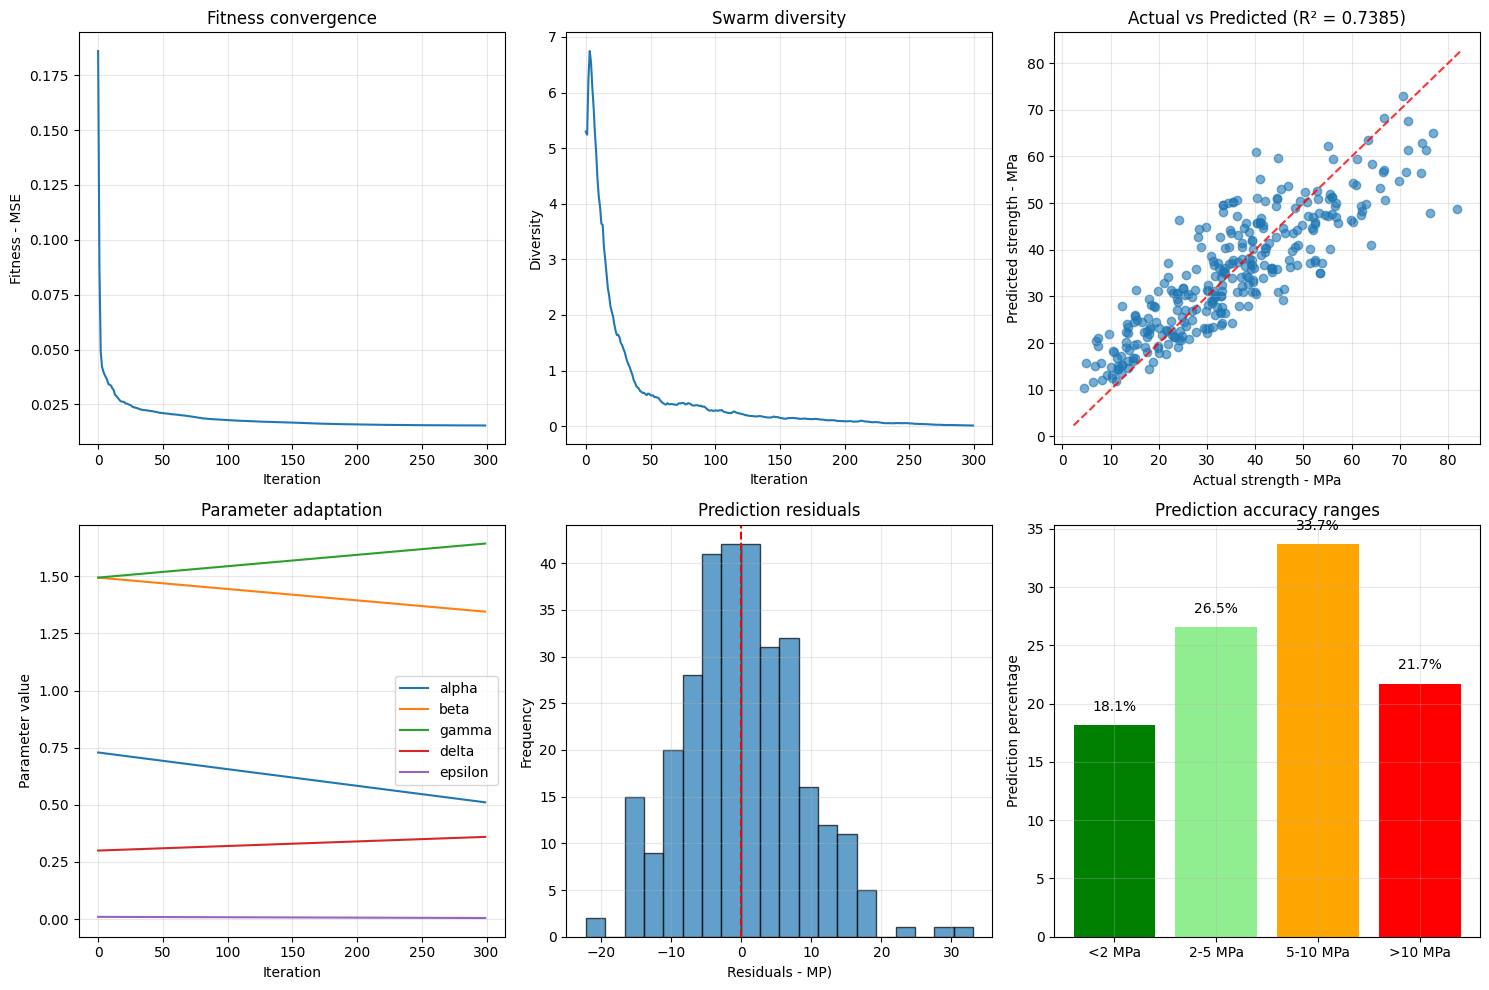

In [10]:
if __name__ == "__main__":
    main()

# MAIN FUNCTION -- 2. Comprehensive Experimental Study Results

In [11]:
if __name__ == "__main__":
    main()

-----------------------------------------------------------------
Biologically Inspired Computation Coursework
ANN + PSO Algorithm 39 for Concrete strength prediction
-----------------------------------------------------------------

 Loading and preprocessing data....
 Using the 8 input features:
  Features: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate ', 'age']
Data prepared: 8 input features (as specified)
Training samples: 721, Test samples: 309

Select mode:

Choose operation mode:
  1. Single Training Run
  2. Comprehensive Experimental Study

 Starting with 10 runs per experiment for comprehensive experimental study 

---------------------------------------------------------------------------
Cmprehensive experimental investigation
----------------------------------------------------------------------

 Architecture effects(10 runs each)
------------------------------------------------------------
Testing 4 architec